In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats, torch
import random
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap, Normalize

### plot setting

In [2]:
# sns.set(context='paper')

# keep text editable in svg
plt.rcParams['svg.fonttype'] = 'none'

import matplotlib as mpl
# push ticks inward
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
# remove top and right splines
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

### helpers

In [3]:
def set_seed(seed: int):
    # Reproducibility for python/numpy/torch RNGs
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def make_trials(n_stim=20, boundaries=(0.25, 0.5, 0.75)):
    """
    Build full factorial trial table following the actual task design.

    A single baseline list (b=0.50, uniform) is generated once.  The other
    conditions slice directly from it so overlapping stim values are
    bit-for-bit identical across conditions.

    b=0.50 : all 20 base stims                                 — 5 stims per quartile
    b=0.25 : base[0:5]    duplicated ×2  (compressed below b)
             + base[5:15]                (expanded above b, up to 0.75)
    b=0.75 : base[5:15]                  (expanded below b, down to 0.25)
             + base[15:20] duplicated ×2 (compressed above b)

    Each boundary yields exactly 10 class-0 and 10 class-1 trials by construction.

    Columns
    -------
    stim_idx        : row-level rank within boundary (0-19).
    unique_stim_idx : identity-level rank; duplicate pairs share the same index.
    """
    n_half = n_stim // 4   # stims per quartile = 5

    # one canonical baseline — all other conditions slice from this
    base_stims = np.linspace(0, 1, n_stim + 2, dtype=np.float32)[1:-1]  # 20 values
    base_stims = np.linspace(0.025, 0.975, 20)

    rows = []
    for b in boundaries:
        if b == 0.50:
            stim_values = base_stims                                              # all 20
            unique_ids  = list(range(n_stim))

        elif b == 0.25:
            compressed  = base_stims[:n_half]                                    # base[0:5]
            expanded    = base_stims[n_half : n_half + n_stim // 2]              # base[5:15]
            stim_values = np.concatenate([np.repeat(compressed, 2), expanded])   # 10 + 10
            unique_ids  = (
                [i for i in range(n_half) for _ in range(2)]          # 0,0,1,1,...,4,4
                + list(range(n_half, n_half + n_stim // 2))           # 5..14
            )

        elif b == 0.75:
            expanded    = base_stims[n_half : n_half + n_stim // 2]              # base[5:15]
            compressed  = base_stims[n_half + n_stim // 2:]                      # base[15:20]
            stim_values = np.concatenate([expanded, np.repeat(compressed, 2)])   # 10 + 10
            unique_ids  = (
                list(range(n_stim // 2))                                          # 0..9
                + [n_stim // 2 + i for i in range(n_half) for _ in range(2)]     # 10,10,...,14,14
            )

        for i, (stim, uid) in enumerate(zip(stim_values, unique_ids)):
            cls = float(stim >= b)
            rows.append({
                'boundary':        float(b),
                'boundary_label':  f'b={b:.2f}',
                'stim':            float(stim),
                'stim_idx':        int(i),
                'unique_stim_idx': int(uid),
                'class':           cls,
            })

    return pd.DataFrame(rows)


def split_train_test(df, test_frac=0.2, seed=1):
    """
    Deterministic train/test split that keeps duplicate stim pairs together.

    Stratifies by boundary first (guaranteeing each condition contributes test
    samples), then groups rows by unique_stim_idx so that both copies of a
    duplicated stimulus always land in the same split half — preventing leakage.
    """
    rng = np.random.default_rng(seed)
    test_idx = []

    for _, b_grp in df.groupby('boundary'):
        # One group = all rows sharing a unique_stim_idx within this boundary.
        # Duplicated stims have 2 rows; unique stims have 1 row.
        groups = [g.index.to_numpy() for _, g in b_grp.groupby('unique_stim_idx')]
        rng.shuffle(groups)

        # At least 1 group from each boundary goes to test.
        n_test_groups = max(1, int(round(len(groups) * test_frac)))
        for grp_rows in groups[:n_test_groups]:
            test_idx.extend(grp_rows)

    test_idx  = np.array(sorted(test_idx))
    train_idx = df.index.difference(test_idx)

    return (
        df.loc[train_idx].reset_index(drop=True),
        df.loc[test_idx].reset_index(drop=True),
    )


def df_to_tensors(df):
    # Convert dataframe columns into model input/target tensors
    X = torch.tensor(df[['stim', 'boundary']].values.copy(), dtype=torch.float32)
    y_class = torch.tensor(df[['class']].values.copy(), dtype=torch.float32)
    y_stim = torch.tensor(df[['stim']].values.copy(), dtype=torch.float32)
    y_bound = torch.tensor(df[['boundary']].values.copy(), dtype=torch.float32)
    return X, y_class, y_stim, y_bound

# --- Expand unique trials (identical reps, no stim variability) ---
def expand_trials(unique_trials_df, n_reps=10):
    """
    For each unique trial, generate n_reps identical copies.
    Returns a new DataFrame with a 'rep' column.
    """
    all_trials = []
    for idx, row in unique_trials_df.iterrows():
        for rep in range(n_reps):
            new_row = row.copy()
            new_row['rep'] = rep
            all_trials.append(new_row)
    all_trials_df = pd.DataFrame(all_trials).reset_index(drop=True)
    return all_trials_df


### generating base trials

In [4]:
# config
n_stim = 20
boundaries = (0.25, 0.5, 0.75)
n_nets = 30

# generate 60 unique trials
trials_df = make_trials(n_stim=n_stim, boundaries=boundaries)
assert len(trials_df) == 60

# # each boundary must have exactly n_stim/2 trials per class (balanced by construction)
# for b, grp in trials_df.groupby('boundary'):
#     assert int(grp['class'].sum()) == n_stim // 2, f'Class imbalance at boundary={b}'



### repeating variable versions of base trials to create all_trials_df

In [5]:
# --- Generate trials and stratified split ---
# Parameters
n_reps = 10
stim_noise_sd = 0.1       # noise added to X_train tensors (regularization)
split_seed = 20260309
use_train_test_split = True
test_frac = 0.30
base_seed = 20260309

# Expand trials (identical reps, no stim variability)
all_trials_df = expand_trials(trials_df, n_reps=n_reps)

# Stratified split: for each unique trial, randomly assign reps to train/test
train_idx, test_idx = [], []
for uid, group in all_trials_df.groupby(['unique_stim_idx', 'boundary', 'class']):
    idxs = group.index.to_numpy().copy()
    n_test = int(np.round(len(idxs) * test_frac))
    n_test = max(1, n_test)  # at least 1 per group
    np.random.default_rng(split_seed).shuffle(idxs)
    test_idx.extend(idxs[:n_test])
    train_idx.extend(idxs[n_test:])

train_df = all_trials_df.loc[train_idx].reset_index(drop=True)
test_df = all_trials_df.loc[test_idx].reset_index(drop=True)

print(f'Trials: {len(all_trials_df)} | Train: {len(train_df)} | Test: {len(test_df)}')
train_df.head()

Trials: 600 | Train: 420 | Test: 180


,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class,rep
0,0.25,b=0.25,0.025,0,0,0.0,6
1,0.25,b=0.25,0.025,0,0,0.0,9
2,0.25,b=0.25,0.025,0,0,0.0,7
3,0.25,b=0.25,0.025,0,0,0.0,8
4,0.25,b=0.25,0.025,1,0,0.0,3


### format data to tensors

In [6]:
# convert to tensors
# X_train: stim + noise (regularization); X_test: clean stim
X_train = torch.tensor(
    train_df[['stim', 'boundary']].values.copy() + np.concatenate([np.random.normal(0, stim_noise_sd, size=(len(train_df), 1)), np.zeros((len(train_df), 1))], axis=1),
    dtype=torch.float32
    )
y_class_train = torch.tensor(train_df[['class']].values.copy(), dtype=torch.float32)
y_stim_train = torch.tensor(train_df[['stim']].values.copy(), dtype=torch.float32)
y_bound_train = torch.tensor(train_df[['boundary']].values.copy(), dtype=torch.float32)

X_test = torch.tensor(
    test_df[['stim', 'boundary']].values.copy(),
    dtype=torch.float32
    )
y_class_test = torch.tensor(test_df[['class']].values.copy(), dtype=torch.float32)
y_stim_test = torch.tensor(test_df[['stim']].values.copy(), dtype=torch.float32)
y_bound_test = torch.tensor(test_df[['boundary']].values.copy(), dtype=torch.float32)

X_full = torch.tensor(
    all_trials_df[['stim', 'boundary']].values.copy() + np.concatenate([np.random.normal(0, stim_noise_sd, size=(len(all_trials_df), 1)), np.zeros((len(all_trials_df), 1))], axis=1),
    dtype=torch.float32
    )
y_class_full = torch.tensor(all_trials_df[['class']].values.copy(), dtype=torch.float32)
y_stim_full = torch.tensor(all_trials_df[['stim']].values.copy(), dtype=torch.float32)
y_bound_full = torch.tensor(all_trials_df[['boundary']].values.copy(), dtype=torch.float32)

# data loaders
batch_size = int((1-test_frac)*n_reps*60)
train_ds = TensorDataset(X_train, y_class_train, y_stim_train, y_bound_train)
test_ds = TensorDataset(X_test, y_class_test, y_stim_test, y_bound_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

train_loader, test_loader

(<torch.utils.data.dataloader.DataLoader at 0x7f47b7fedb90>,
 <torch.utils.data.dataloader.DataLoader at 0x7f47f8848590>)

### network architecture, training rules

In [7]:
# --- Architecture ---
class BoundaryNet(nn.Module):
    """
    2-input → 10-unit hidden → 1-output boundary-classification network.
    Inputs : [stim ∈ (0,1),  boundary ∈ {0.25, 0.50, 0.75}]
    Hidden : 10 units, ReLU
    Output : linear  →  response ∈ (0,1)
    """
    def __init__(self, in_dim: int = 2, hidden_dim: int = 5):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = F.relu(self.fc1(x))
        return self.fc2(h)

    def forward_with_hidden(self, x: torch.Tensor):
        """Return (output, hidden_activations) for neural analysis."""
        h = F.relu(self.fc1(x))
        out = self.fc2(h)
        return out, h

def correlation_loss(pred, target):
    pred = pred.squeeze()
    target = target.squeeze()
    vx = pred - pred.mean()
    vy = target - target.mean()
    corr = (vx * vy).sum() / (torch.sqrt((vx ** 2).sum()) * torch.sqrt((vy ** 2).sum()) + 1e-8)
    return 1 - corr  # or -corr if you want to maximize

# --- Training / evaluation epoch ---
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    ctx = torch.enable_grad() if training else torch.no_grad()

    totals = dict(total=0.0, loss_stim=0.0, loss_exp_bound=0.0, correct=0, n=0)
    pred_list, stim_list = [], []

    with ctx:
        for X, y_class_b, y_stim_b, y_bound_b in loader:
            pred = model(X)
            pred_list.append(pred.detach())
            stim_list.append(y_stim_b)

            # Compressed-class mask
            is_comp = (
                ((y_class_b == 0) & (y_bound_b < 0.5)) |
                ((y_class_b == 1) & (y_bound_b > 0.5))
            ).squeeze(1)
            is_exp = ~is_comp

            # Loss 1: Stimulus MSE — all trials
            stim_loss = F.mse_loss(pred, y_stim_b) # * swtim_mse_wt

            # Loss 2: Boundary pull — expanded-class trials only
            if is_exp.any():
                exp_bound_loss = F.mse_loss(pred[is_exp], y_bound_b[is_exp]) # * exp_bound_wt
            else:
                exp_bound_loss = torch.tensor(0.0)

            # loss = stim_loss + exp_bound_loss
            loss = (stim_mse_wt * stim_loss) + (exp_bound_wt * exp_bound_loss) + corr_wt * correlation_loss(pred, y_stim_b)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_n = X.size(0)
            totals['total']          += loss.item()           * batch_n
            totals['loss_stim']      += stim_loss.item()      * batch_n
            totals['loss_exp_bound'] += exp_bound_loss.item() * batch_n
            y_bound_thresh = X[:, 1:2]
            totals['correct'] += ((pred >= y_bound_thresh).float() == y_class_b).sum().item()
            totals['n']       += batch_n

    n       = max(totals.pop('n'), 1)
    correct = totals.pop('correct')
    return {k: v / n for k, v in totals.items()} | {'acc': correct / n}

# --- inference with hidden activations, typically only on test_df ---
def evaluate_model_on_df(model, df):
    """
    Run inference on every row of *df* in one shot (no shuffling).
    Returns
    -------
    pred_df : copy of df with 'resp' and 'class_pred' columns added
    hidden  : np.ndarray  [n_trials, hidden_dim]
    metrics : dict
    """
    model.eval()
    X = torch.tensor(df[['stim', 'boundary']].values.copy(), dtype=torch.float32)
    y_class = torch.tensor(df[['class']].values.copy(), dtype=torch.float32)
    y_stim = torch.tensor(df[['stim']].values.copy(), dtype=torch.float32)
    y_bound = torch.tensor(df[['boundary']].values.copy(), dtype=torch.float32)

    with torch.no_grad():
        out, h = model.forward_with_hidden(X)

    resp   = out.squeeze(1).numpy()
    hidden = h.numpy()

    pred_df = df.copy()
    pred_df['resp']       = resp
    pred_df['class_pred'] = (resp >= df['boundary'].values).astype(float)

    ds      = TensorDataset(X, y_class, y_stim, y_bound)
    loader  = DataLoader(ds, batch_size=len(df), shuffle=False)
    metrics = run_epoch(model, loader, optimizer=None)

    return pred_df, hidden, metrics

print('BoundaryNet, run_epoch, and evaluate_model_on_df defined.')
BoundaryNet()

BoundaryNet, run_epoch, and evaluate_model_on_df defined.


BoundaryNet(
  (fc1): Linear(in_features=2, out_features=5, bias=True)
  (fc2): Linear(in_features=5, out_features=1, bias=True)
)

### Train/Test cycle

In [8]:
# training setup
max_epochs = 250   # hard cap — training always stops here even without convergence
min_epochs = 15    # burn-in period: convergence is not checked before this epoch
conv_target = 0.8 # rolling-window train accuracy that triggers early stopping
mse_target = 0.005  # rolling-window train_loss_stim that triggers early stopping
conv_window = 20   # number of recent epochs averaged to assess convergence
lr = 1e-2
stim_mse_wt  = 2  # MSE toward raw stimulus value — applied to ALL trials
exp_bound_wt = 1   # MSE toward boundary — applied to expanded-class trials only
corr_wt = 0     # NEW: weight for correlation loss (if used)

network_results = []

for net_idx in range(n_nets):
    # Each network gets a unique but deterministic seed derived from the base seed,
    # so the ensemble is reproducible while each member is independently initialized.
    seed = base_seed + net_idx
    set_seed(seed)

    # Fresh model and optimizer for every network in the ensemble.
    model = BoundaryNet(in_dim=2, hidden_dim=10)
    optimizer = Adam(model.parameters(), lr=lr)

    network_epochs = []       # per-epoch stats for this network
    converged = False  # flag: did this network meet the early-stopping criterion?

    for epoch in range(max_epochs):
        # --- Training pass: gradients are computed and weights are updated. ---
        train_stats = run_epoch(model, train_loader, optimizer=optimizer)

        # --- Evaluation pass: no gradient updates, held-out test set only. ---
        test_stats = run_epoch(model, test_loader, optimizer=None)

        # Store both train and test stats for this epoch with prefixed keys.
        row = {
            'net_idx': net_idx,
            'seed': seed,
            'epoch': epoch,
            **{f"train_{k}": v for k, v in train_stats.items()},
            **{f"test_{k}": v for k, v in test_stats.items()},
        }
        network_epochs.append(row)

        # Early stopping check: only after burn-in and once enough epochs exist.
        if epoch >= min_epochs and len(network_epochs) >= conv_window:
            # Average train accuracy and loss_stim over the last `conv_window` epochs.
            recent_train_acc   = np.mean([h['train_acc']  for h in network_epochs[-conv_window:]])
            if recent_train_acc >= conv_target:
                converged = True
                break  # exit the epoch loop; model is considered trained

    network_epochs_df = pd.DataFrame(network_epochs)

    # Final inference on every trial (including training trials) to get
    # a complete picture of the learned response function and hidden activations.
    # full_pred_df, hidden_full, full_metrics = evaluate_model_on_df(model, all_trials_df)
    test_pred_df, hidden_test, test_metrics = evaluate_model_on_df(model, test_df)

    # Bundle everything for this network into a single dict so it can be accessed
    # uniformly when aggregating results across the ensemble.
    network_results.append(
        {
            'net_idx': net_idx,
            'seed': seed,
            'model': model,
            'epoch_results': network_epochs_df,
            'converged': converged,
            'epochs_ran': int(network_epochs_df['epoch'].max() + 1),
            # 'full_pred_df': full_pred_df,
            'test_pred_df': test_pred_df,
            # 'hidden_full': hidden_full,   # shape: [60, hidden_dim] — used for PCA
            'hidden_test': hidden_test,
            # 'full_metrics': full_metrics,
            'test_metrics': test_metrics,
        }
    )

nets_summarized_df = pd.DataFrame(
    {
        'net_idx': [net['net_idx'] for net in network_results],
        'seed': [net['seed'] for net in network_results],
        'converged': [net['converged'] for net in network_results],
        'epochs_ran': [net['epochs_ran'] for net in network_results],
        'test_acc': [net['test_metrics']['acc'] for net in network_results],
        'test_total_loss': [net['test_metrics']['total'] for net in network_results],
    }
)

nets_summarized_df.describe(include='all')

,net_idx,seed,converged,epochs_ran,test_acc,test_total_loss
count,30.000000,3.000000e+01,30,30.000000,30.000000,30.000000
unique,NaN,NaN,1,NaN,NaN,NaN
top,NaN,NaN,True,NaN,NaN,NaN
freq,NaN,NaN,30,NaN,NaN,NaN
mean,14.500000,2.026032e+07,NaN,71.600000,0.933333,0.056073
std,8.803408,8.803408e+00,NaN,26.029956,0.037651,0.003586
min,0.000000,2.026031e+07,NaN,33.000000,0.866667,0.048982
25%,7.250000,2.026032e+07,NaN,49.000000,0.916667,0.053782
50%,14.500000,2.026032e+07,NaN,66.000000,0.933333,0.055571
75%,21.750000,2.026033e+07,NaN,90.750000,0.966667,0.058133


### Check results

In [9]:
print('Convergence rate:', nets_summarized_df['converged'].mean())
print('Mean epochs run:',  nets_summarized_df['epochs_ran'].mean())
# sd dev epochs
print('Std  epochs run:',  nets_summarized_df['epochs_ran'].std())
print('Min epochs run:',  nets_summarized_df['epochs_ran'].min())
print('Max epochs run:',  nets_summarized_df['epochs_ran'].max())
print('Mean test accuracy:', nets_summarized_df['test_acc'].mean())
print('Std  test accuracy:', nets_summarized_df['test_acc'].std())

nets_summarized_df.head()


Convergence rate: 1.0
Mean epochs run: 71.6
Std  epochs run: 26.029956217590055
Min epochs run: 33
Max epochs run: 118
Mean test accuracy: 0.9333333333333333
Std  test accuracy: 0.037651354837147585


,net_idx,seed,converged,epochs_ran,test_acc,test_total_loss
0,0,20260309,True,45,0.933333,0.060465
1,1,20260310,True,44,0.966667,0.056197
2,2,20260311,True,79,0.933333,0.059629
3,3,20260312,True,66,0.933333,0.055352
4,4,20260313,True,58,0.933333,0.051465


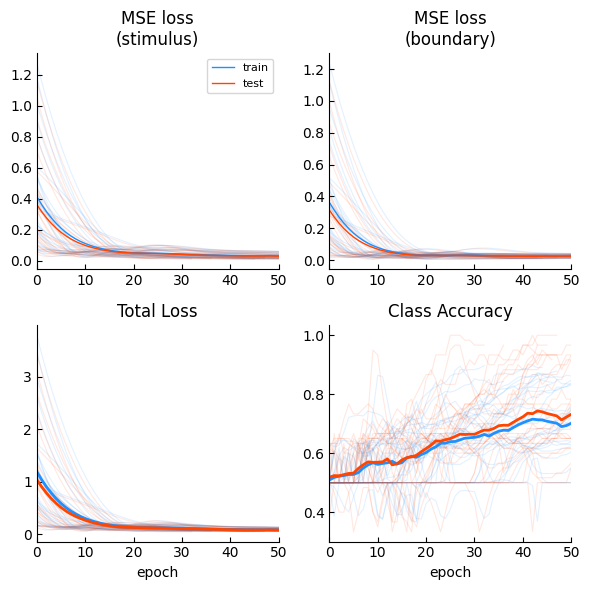

In [10]:
# ── Concatenate all per-epoch records across networks ─────────────────────────
all_epochs = pd.concat(
    [r['epoch_results'] for r in network_results],
    ignore_index=True,
    )

epoch2plot = nets_summarized_df['epochs_ran'].quantile(.5)
epoch2plot = 50

# ── 2×2 grid: losses and accuracy ─────────────────────────────────────────────
fig, axs = plt.subplots(2, 2, figsize=(6, 6))
axs = axs.flatten()

# Top row: MSE and exp_bound losses
for ax, (title, train_col, test_col) in zip([axs[0], axs[1]], [
    ('MSE loss\n(stimulus)',        'train_loss_stim',      'test_loss_stim'),
    ('MSE loss\n(boundary)',  'train_loss_exp_bound', 'test_loss_exp_bound'),
]):
    for _, grp in all_epochs.groupby('net_idx'):
        ax.plot(grp['epoch'], grp[train_col], color='dodgerblue', alpha=0.12, linewidth=0.8)
        ax.plot(grp['epoch'], grp[test_col],  color='orangered',  alpha=0.12, linewidth=0.8)

    mn = all_epochs.groupby('epoch')[[train_col, test_col]].mean()
    ax.plot(mn.index, mn[train_col], color='dodgerblue', linewidth=1, label='train')
    ax.plot(mn.index, mn[test_col],  color='orangered',  linewidth=1, label='test')

    ax.set(title=title, ylabel='', xlim=(0, epoch2plot))
    axs[0].legend(fontsize=8)

# Bottom row: total loss and classification accuracy
for ax, (title, train_col, test_col) in zip([axs[2], axs[3]], [
    ('Total Loss', 'train_total',          'test_total'),
    ('Class Accuracy', 'train_acc',        'test_acc'),
]):
    for _, grp in all_epochs.groupby('net_idx'):
        ax.plot(grp['epoch'], grp[train_col], color='dodgerblue', alpha=0.12, linewidth=0.8)
        ax.plot(grp['epoch'], grp[test_col],  color='orangered',  alpha=0.12, linewidth=0.8)

    mn = all_epochs.groupby('epoch')[[train_col, test_col]].mean()
    ax.plot(mn.index, mn[train_col], color='dodgerblue', linewidth=2, label='train')
    ax.plot(mn.index, mn[test_col],  color='orangered',  linewidth=2, label='test')

    ax.set(title=title, xlabel='epoch', ylabel='', xlim=(0, epoch2plot))
    # ax.legend(fontsize=8)

# plt.suptitle('n=30')
plt.tight_layout()
# plt.savefig('../../figs/ccn/net-training.svg', format='svg')
plt.show()

### Behavior

response distributions

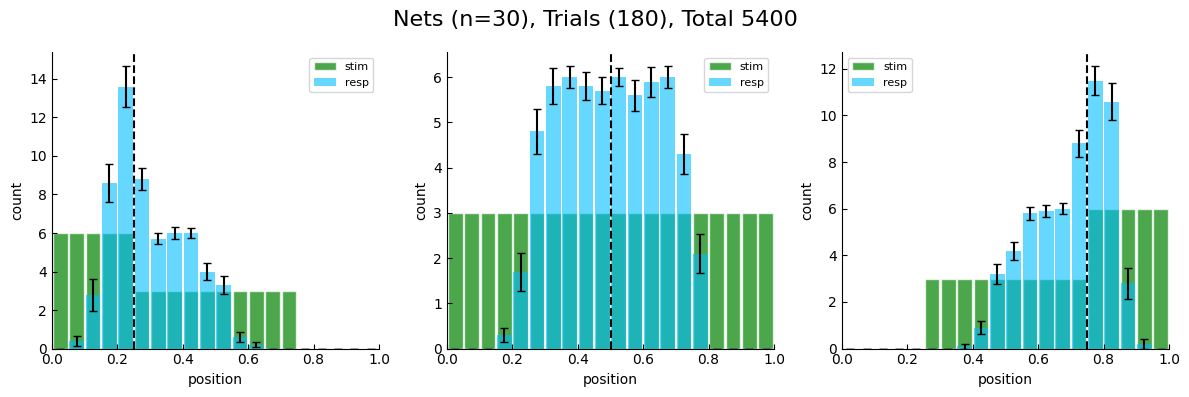

In [11]:
# collect all network predictions on test set only
beh_df = pd.concat(
    [network_result['test_pred_df'].assign(net_idx=network_result['net_idx']) for network_result in network_results],
    ignore_index=True,
)

# shared config
b_colors = {0.25: 'orangered', 0.50: 'gray', 0.75: 'dodgerblue'}
n_bins = 20

# --- Plot 1: Response histogram (1×3, per boundary) ---
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs, ax = axs.flatten(), 0
cond_titles = ['curv_comp', 'baseline', 'flat_comp']

for bound in boundaries:
    cond_df = beh_df[beh_df['boundary'] == bound]

    resp_cts = []
    for _, net_df in cond_df.groupby('net_idx'):
        counts, _ = np.histogram(net_df['resp'], bins=n_bins, range=(0, 1))
        resp_cts.append(counts)
    resp_cts = np.array(resp_cts)

    mean_cts = resp_cts.mean(axis=0)
    sem_cts  = resp_cts.std(axis=0) / np.sqrt(resp_cts.shape[0])
    bin_centers = np.linspace(0, 1, n_bins, endpoint=False) + 0.5 / n_bins

    # true stimulus distribution for this boundary (noisy)
    stim_vals = test_df[test_df['boundary'] == bound]['stim'].values
    stim_cts, _ = np.histogram(stim_vals, bins=n_bins, range=(0, 1))

    # overlay: stim dist in muted color behind, response dist in front
    axs[ax].bar(bin_centers, stim_cts, width=1/n_bins * 0.9, color='green', edgecolor='white', alpha=0.7, label='stim')
    axs[ax].bar(bin_centers, mean_cts, width=1/n_bins * 0.9, color='deepskyblue', alpha=0.6, yerr=sem_cts, capsize=3, label='resp')
    axs[ax].axvline(bound, color='black', linestyle='--')
    axs[ax].set(xlabel='position', ylabel='count', xlim=(0, 1))
    axs[ax].legend(fontsize=8)
    ax += 1

plt.suptitle(f'Nets (n=30), Trials ({len(test_df)}), Total {len(beh_df)}', fontsize=16)
plt.tight_layout()
plt.show()


In [12]:
len(test_df), len(beh_df)

(180, 5400)

In [13]:
for b in boundaries:
    print(f'\n=== b={b:.2f} ===')
    for cls in [0, 1]:
        sub = beh_df[(beh_df['boundary'] == b) & (beh_df['class'] == cls)]
        print(f'  class={int(cls)}: mean_stim={sub["stim"].mean():.3f}  mean_resp={sub["resp"].mean():.3f}  '
              f'r={stats.pearsonr(sub["stim"], sub["resp"])[0]:.3f}')


=== b=0.25 ===
  class=0: mean_stim=0.125  mean_resp=0.209  r=0.674
  class=1: mean_stim=0.500  mean_resp=0.395  r=0.896

=== b=0.50 ===
  class=0: mean_stim=0.250  mean_resp=0.368  r=0.947
  class=1: mean_stim=0.750  mean_resp=0.628  r=0.947

=== b=0.75 ===
  class=0: mean_stim=0.500  mean_resp=0.601  r=0.917
  class=1: mean_stim=0.875  mean_resp=0.794  r=0.833


In [14]:
# ── Confusion matrix components by boundary condition ────────────────────────
for b in boundaries:
    sub = beh_df[beh_df['boundary'] == b]
    y_true = sub['class'].values
    y_pred = (sub['resp'].values >= b).astype(float)

    tp = ((y_pred == 1) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()

    print(f'b={b:.2f} | TP={tp:4d}  TN={tn:4d}  FP={fp:4d}  FN={fn:4d}  '
          f'acc={( tp + tn) / (tp + tn + fp + fn):.3f}')

b=0.25 | TP= 882  TN= 744  FP= 156  FN=  18  acc=0.903
b=0.50 | TP= 888  TN= 891  FP=   9  FN=  12  acc=0.988
b=0.75 | TP= 744  TN= 891  FP=   9  FN= 156  acc=0.908


stim vs resp

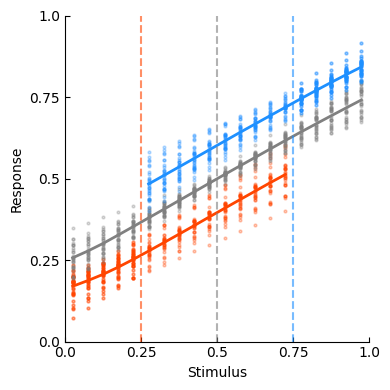

In [15]:
# --- Plot 2: Raw stim vs resp ---
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for b in boundaries:
    sub = beh_df[beh_df['boundary'] == b]
    ax.plot(sub['stim'], sub['resp'], 'o', markersize=2, alpha=0.1, color=b_colors[b])
    mean_resp = sub.groupby('stim')['resp'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2, label=f'b={b:.2f}', color=b_colors[b])

for b in boundaries:
    ax.axvline(b, color=b_colors[b], linestyle='--', alpha=0.6)

ticks_labels = np.linspace(0, 1, 5)
ax.set(xlabel='Stimulus', ylabel='Response', xlim=(0, 1), ylim=(0, 1),
       xticks=ticks_labels, yticks=ticks_labels, xticklabels=ticks_labels, yticklabels=ticks_labels)
# ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../../figs/ccn/beh-net-stim_vs_resp.svg', format='svg')
plt.show()


### stim vs resp, boundary-aligned

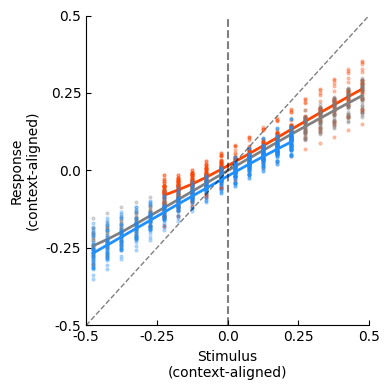

In [16]:
# --- Plot 3: Boundary-aligned stim vs resp (noisy stim) ---
beh_df['stim_aligned'] = beh_df['stim'] - beh_df['boundary']
beh_df['resp_aligned'] = beh_df['resp'] - beh_df['boundary']

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for b in boundaries:
    sub = beh_df[beh_df['boundary'] == b]
    ax.plot(sub['stim_aligned'], sub['resp_aligned'], 'o', markersize=2, alpha=0.1, color=b_colors[b])
    mean_resp = sub.groupby('stim_aligned')['resp_aligned'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2, label=f'b={b:.2f}', color=b_colors[b])

ticks_labels = np.linspace(-0.5, 0.5, 5)
ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
ax.plot([-0.5, 0.5], [-0.5, 0.5], color = 'black', linewidth=1, linestyle='--', alpha=0.5)
ax.set(xlabel='Stimulus\n(context-aligned)', ylabel='Response\n(context-aligned)',
       xlim=(-0.5, 0.5), ylim=(-0.5, 0.5),
       xticks=ticks_labels, yticks=ticks_labels,
       xticklabels=ticks_labels, yticklabels=ticks_labels)
# ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../../figs/ccn/beh-net-stim_vs_resp_aligned.svg', format='svg')
plt.show()


### test for context-shifts

In [17]:
# --- Context-shift alignment MSEs: within vs between ---
from itertools import combinations
import numpy as np

# Bins over the overlapping stim_aligned range across all contexts
bin_edges = np.linspace(-0.75, 0.75, 21)  # 20 bins of width 0.075

all_within_MSEs = []   # per net
all_between_MSEs = []  # per net

for net_idx in beh_df['net_idx'].unique():
    net_df = beh_df[beh_df['net_idx'] == net_idx]

    # Within-context MSEs (stim_aligned vs resp_aligned for each context)
    net_within_MSEs = []
    for bound in boundaries:
        context_df = net_df[net_df['boundary'] == bound]
        mse = np.mean((context_df['stim_aligned'].values - context_df['resp_aligned'].values) ** 2)
        net_within_MSEs.append(mse)
    all_within_MSEs.append(np.mean(net_within_MSEs))

    # Between-context MSEs: match on stim_aligned bins (NOT unique_stim_idx, which
    # resets per boundary and does not identify the same stimulus across conditions)
    net_between_MSEs = []
    for bound1, bound2 in combinations(boundaries, 2):
        c1_df = net_df[net_df['boundary'] == bound1]
        c2_df = net_df[net_df['boundary'] == bound2]

        c1_bins = pd.cut(c1_df['stim_aligned'], bins=bin_edges, labels=False)
        c2_bins = pd.cut(c2_df['stim_aligned'], bins=bin_edges, labels=False)

        c1_mean = c1_df.groupby(c1_bins)['resp_aligned'].mean()
        c2_mean = c2_df.groupby(c2_bins)['resp_aligned'].mean()

        common_bins = c1_mean.index.intersection(c2_mean.index)
        if len(common_bins) == 0:
            mse = np.nan
        else:
            mse = np.mean((c1_mean.loc[common_bins].values - c2_mean.loc[common_bins].values) ** 2)
        net_between_MSEs.append(mse)
    all_between_MSEs.append(np.nanmean(net_between_MSEs))

all_within_MSEs = np.array(all_within_MSEs)
all_between_MSEs = np.array(all_between_MSEs)

Paired t-test: t = -16.20767232829075 p = 4.483745071688996e-16


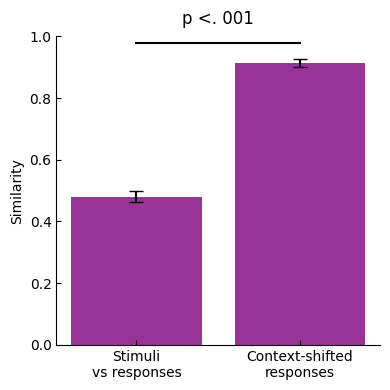

In [22]:
from scipy.stats import ttest_rel

# --- Bar plot: Within vs Between context alignment MSEs ---
fig, axs = plt.subplots(1, 1, figsize=(4, 4))
axs = [axs]  # flatten for consistent indexing
ax = 0

alpha = 50  # adjust as needed for your scale
test_means = all_within_MSEs
test_sds = all_between_MSEs

test_means = np.exp(-alpha * all_within_MSEs)
test_sds = np.exp(-alpha * all_between_MSEs)

means = [test_means.mean(), test_sds.mean()]
sems = [test_means.std() / np.sqrt(len(test_means)),
        test_sds.std() / np.sqrt(len(test_sds))]

bars = axs[ax].bar([0, 1], means, yerr=sems, capsize=5, color=['purple', 'purple'], alpha=0.8)
axs[ax].set(xticks=[0, 1], xticklabels=['Stimuli\nvs responses', 'Context-shifted\nresponses'], ylabel='Similarity')
axs[ax].grid(False)  # Remove grid
# axs[ax].set_title('Responses are Shifted by Contexts')

# Draw only horizontal line connecting bar tops
bar_tops = [means[0] + sems[0], means[1] + sems[1]]
line_y = max(bar_tops) + 0.05
axs[ax].plot([0, 1], [line_y, line_y], color='black', linewidth=1.5)

# Place stars just above the line, within plot area
t_stat, p_val = ttest_rel(test_means, test_sds)
print("Paired t-test: t =", t_stat, "p =", p_val)
axs[ax].text(0.5, line_y + 0.05, 'p <. 001', ha='center', va='bottom', fontsize=12)

# Increase ylim if needed to fit stars
axs[ax].set_ylim(0, line_y + 0.005)
axs[ax].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../../figs/ccn/beh-net-context_similarity.svg', format='svg')
plt.show()

### saves and checks

In [19]:
# Stack hidden layer activations from all 30 networks
# Shape: (n_nets, n_trials, n_hidden_units) = (30, 60, 10)
hidden_stack = np.stack([nr['hidden_test'] for nr in network_results])
print(f'hidden_stack shape: {hidden_stack.shape}')
print(f'hidden_stack contains any NaN: {np.isnan(hidden_stack).any()}')
print(f'hidden_stack contains any inf: {np.isinf(hidden_stack).any()}')

hidden_stack shape: (30, 180, 10)
hidden_stack contains any NaN: False
hidden_stack contains any inf: False


In [20]:
# Verify saved data
print("beh_df columns:", beh_df.columns.tolist())
print("beh_df shape:", beh_df.shape)
print("\nChecking for aligned columns:")
print("  'stim_aligned' in beh_df:", 'stim_aligned' in beh_df.columns)
print("  'resp_aligned' in beh_df:", 'resp_aligned' in beh_df.columns)
if 'stim_aligned' in beh_df.columns:
    print("  stim_aligned sample:", beh_df['stim_aligned'].head().tolist())
if 'resp_aligned' in beh_df.columns:
    print("  resp_aligned sample:", beh_df['resp_aligned'].head().tolist())

beh_df columns: ['boundary', 'boundary_label', 'stim', 'stim_idx', 'unique_stim_idx', 'class', 'rep', 'resp', 'class_pred', 'net_idx', 'stim_aligned', 'resp_aligned']
beh_df shape: (5400, 12)

Checking for aligned columns:
  'stim_aligned' in beh_df: True
  'resp_aligned' in beh_df: True
  stim_aligned sample: [-0.225, -0.225, -0.225, -0.225, -0.225]
  resp_aligned sample: [-0.13883930444717407, -0.13883930444717407, -0.13883930444717407, -0.13883930444717407, -0.13883930444717407]


### save

In [21]:
beh_df.to_csv('../../results/simulations/beh_df.csv', index=False)
np.save('../../results/simulations/hidden_stack.npy', hidden_stack)   # shape (30, 60, 10)
print("Saved: beh_df.csv, hidden_stack.npy")

Saved: beh_df.csv, hidden_stack.npy
